In [55]:
import torch
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [2]:
pcas_squad = torch.load("../data/pcas/squad/opt-125m_0.0_rotation_matrices.pt")

In [3]:
pcas_wikitext = torch.load("../data/pcas/wikitext2/opt-125m_0.0_rotation_matrices.pt")

In [ ]:
a = pcas_squad[10]["eigenvectors"]
b = pcas_wikitext[10]["eigenvectors"]

In [91]:
angles = scipy.linalg.subspace_angles(a[:, :688], b[:, :688])

In [95]:
from scipy.linalg import subspace_angles

def grassman_distance(A, B, k):
    sub_A = A[:, :k]
    sub_B = B[:, :k]

    angles = subspace_angles(sub_A, sub_B)

    grassman_dist = np.linalg.norm(angles)

    return grassman_dist

In [101]:
def plot_grassman_vs_k(A, B, max_k=None, step=1):
    if max_k is None:
        max_k = min(A.shape[1], B.shape[1])

    k_values = list(range(1, max_k + step, step))
    distances = [grassman_distance(A, B, k) for k in k_values]

    plt.figure(figsize=(10, 6))
    plt.plot(k_values, distances, marker='o')
    plt.xlabel('k (Number of Principal Components)')
    plt.ylabel('Grassman Distance')
    plt.title('Grassman Distance vs Number of Principal Components')
    plt.grid()
    plt.show()

In [154]:
def chordal_distance(A, B, k):
    sub_A = A[:, :k]
    sub_B = B[:, :k]

    s = np.linalg.svd(sub_A.T @ sub_B, compute_uv=False)

    chordal_distance = np.sqrt(k - np.sum(s**2))

    return chordal_distance

In [ ]:
def plot_chordal_dist_vs_k(A, B, max_k=None, step=1):
    if max_k is None:
        max_k = min(A.shape[1], B.shape[1])

    k_values = list(range(1, max_k + step, step))
    distances = [chordal_distance(A, B, k) for k in k_values]

    plt.figure(figsize=(10, 6))
    plt.plot(k_values, distances, marker='o')
    plt.xlabel('k (Number of Principal Components)')
    plt.ylabel('Chordal Distance')
    plt.title('Chordal Distance vs Number of Principal Components')
    plt.grid()
    plt.show()

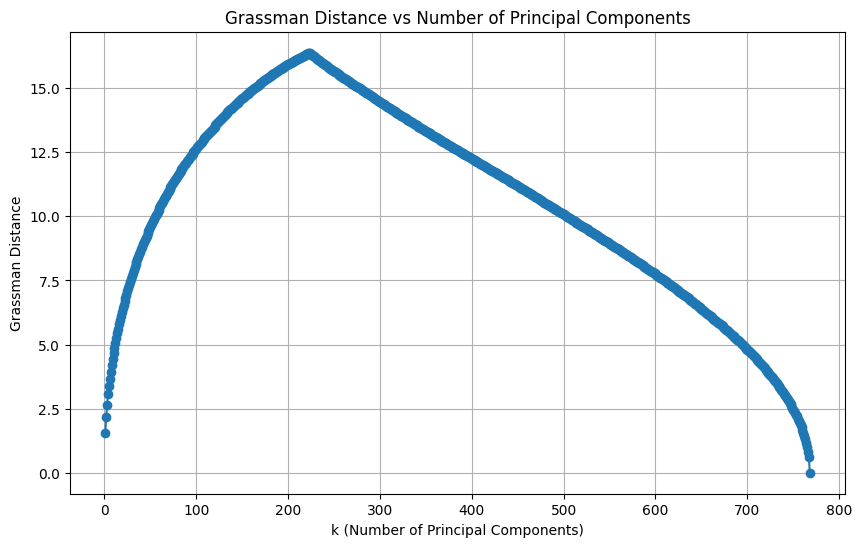

In [98]:
plot_grassman_vs_k(a, b, max_k=768)

In [152]:
a = pcas_squad[0]["eigenvectors"]
b = pcas_wikitext[0]["eigenvectors"]

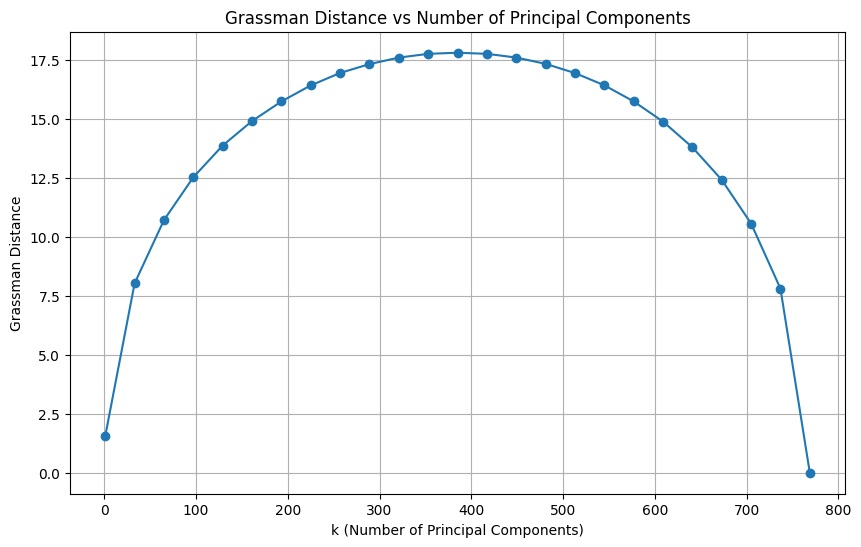

In [153]:
plot_grassman_vs_k(a, b, max_k=768, step=32)

In [120]:
def compute_explained_variance_ratio(eigenvalues):
    eigenvalues = eigenvalues.numpy()
    total_variance = np.sum(eigenvalues)
    explained_variance_ratio = eigenvalues / total_variance
    return explained_variance_ratio

In [121]:
def plot_explained_variance(eigenvalues1, eigenvalues2, max_components=100):
    evr1 = compute_explained_variance_ratio(eigenvalues1)
    evr2 = compute_explained_variance_ratio(eigenvalues2)
    
    n_components = min(max_components, len(evr1))
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Individual explained variance
    axes[0, 0].plot(range(1, n_components + 1), evr1[:n_components], 
                    label='Dataset 1', alpha=0.7)
    axes[0, 0].plot(range(1, n_components + 1), evr2[:n_components], 
                    label='Dataset 2', alpha=0.7)
    axes[0, 0].set_xlabel('Component')
    axes[0, 0].set_ylabel('Explained Variance Ratio')
    axes[0, 0].set_title('Individual Component Variance')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Cumulative explained variance
    cumsum1 = np.cumsum(evr1[:n_components])
    cumsum2 = np.cumsum(evr2[:n_components])
    axes[0, 1].plot(range(1, n_components + 1), cumsum1, label='Dataset 1', alpha=0.7)
    axes[0, 1].plot(range(1, n_components + 1), cumsum2, label='Dataset 2', alpha=0.7)
    axes[0, 1].set_xlabel('Component')
    axes[0, 1].set_ylabel('Cumulative Explained Variance')
    axes[0, 1].set_title('Cumulative Variance')
    axes[0, 1].axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95%')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Log scale for tail
    axes[1, 0].semilogy(range(1, n_components + 1), evr1[:n_components], 
                        label='Dataset 1', alpha=0.7)
    axes[1, 0].semilogy(range(1, n_components + 1), evr2[:n_components], 
                        label='Dataset 2', alpha=0.7)
    axes[1, 0].set_xlabel('Component')
    axes[1, 0].set_ylabel('Explained Variance Ratio (log scale)')
    axes[1, 0].set_title('Variance (Log Scale)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Difference between datasets
    diff = evr1[:n_components] - evr2[:n_components]
    axes[1, 1].plot(range(1, n_components + 1), diff)
    axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[1, 1].set_xlabel('Component')
    axes[1, 1].set_ylabel('Difference (Dataset 1 - Dataset 2)')
    axes[1, 1].set_title('Variance Difference Between Datasets')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"Dataset 1 - Top 10 components explain: {cumsum1[9]:.2%}")
    print(f"Dataset 2 - Top 10 components explain: {cumsum2[9]:.2%}")
    print(f"Dataset 1 - Components for 95% variance: {np.argmax(cumsum1 > 0.95) + 1}")
    print(f"Dataset 2 - Components for 95% variance: {np.argmax(cumsum2 > 0.95) + 1}")

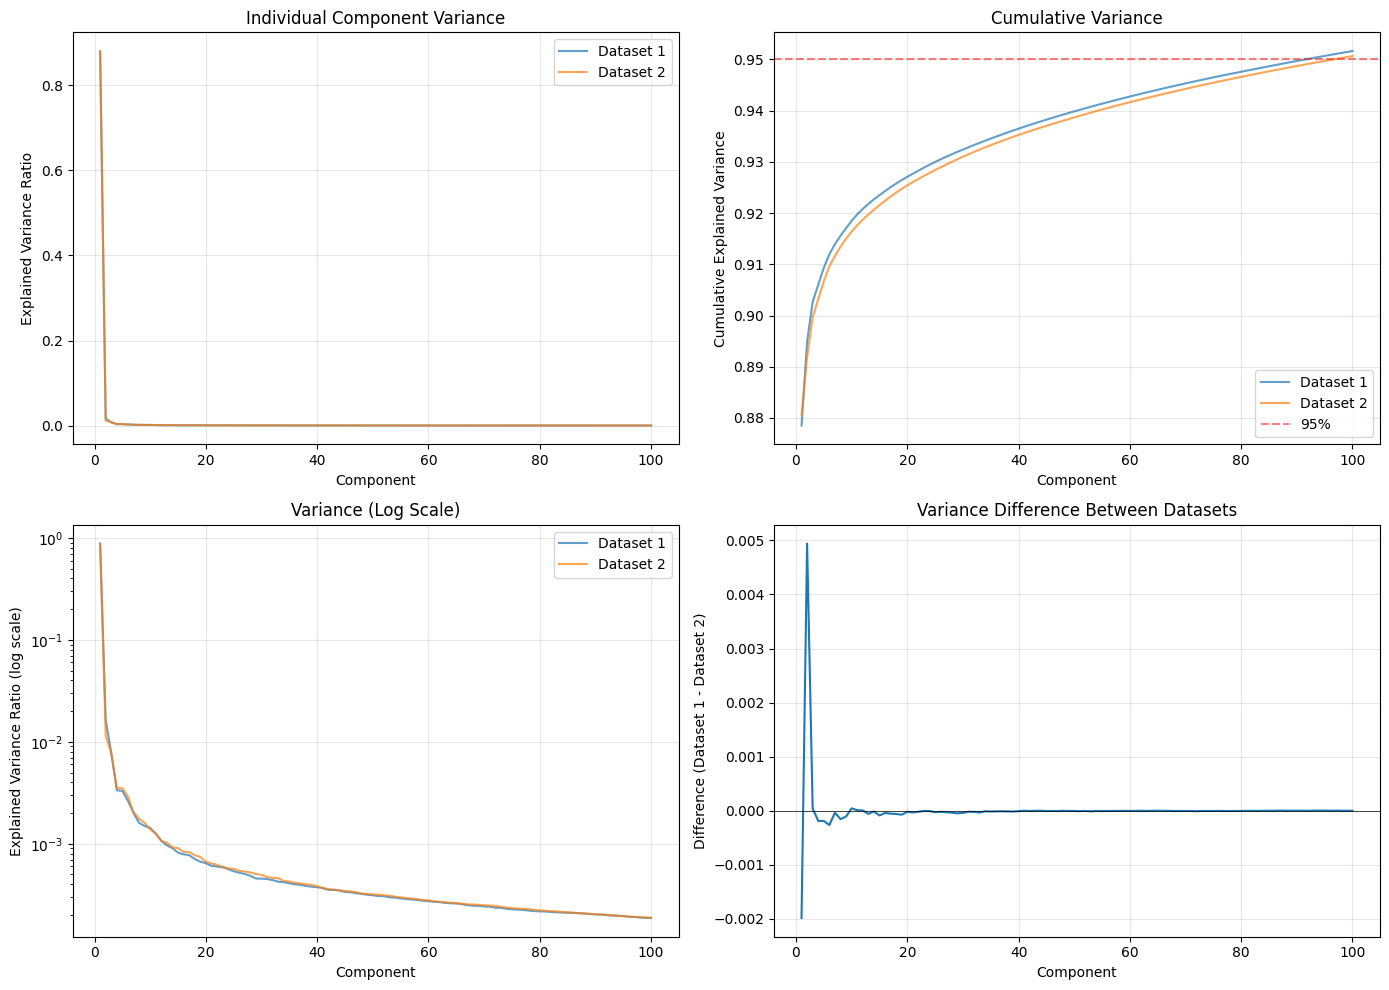

Dataset 1 - Top 10 components explain: 91.85%
Dataset 2 - Top 10 components explain: 91.64%
Dataset 1 - Components for 95% variance: 92
Dataset 2 - Components for 95% variance: 97


In [123]:
eigvA = pcas_squad[10]["eigenvalues"]
eigvB = pcas_wikitext[10]["eigenvalues"]
plot_explained_variance(eigvA, eigvB, max_components=100)